# hMOF Hydrogen Dataset: Deep Dive (EDA)

Goal: understand **everything** in the dataset before changing the model.

1. What fields each JSON file contains (schema)
2. Which isotherm conditions exist (temperatures, pressures, units), and whether **deliverable capacity** (77 K/100 bar → 160 K/5 bar) can be computed
3. Label quality: zeros, negatives, outliers, duplicates
4. Metadata properties (void fraction, surface area, pore sizes, density, if present) and how strongly they correlate with uptake
5. Identifiers (MOFid / MOFkey / topology) that would allow **grouped splits** instead of random splits
6. JSON ↔ CIF matching
7. Structure statistics from a CIF sample (size, density, metals) and uptake by metal
8. Near-duplicate structures (train/test leakage risk)

Run on Kaggle (CPU is enough; Internet on). Everything is saved to the working directory. **At the end, send back the printed "SUMMARY" block** so we can plan the next steps.

## 0. Setup

In [1]:
import os, json, random, subprocess, sys, zipfile, warnings
from collections import Counter, defaultdict
from multiprocessing import Pool, cpu_count

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DATA_URL = ("https://mof.tech.northwestern.edu/Datasets/"
            "hMOF-10%201021%20acs%20jpcc%206b08729-Hydrogen-mofdb-version:dc8a0295db.zip")
ZIP_PATH = "/tmp/data.zip"
RAW_DIR = "/tmp/hMOF_data"
WORK_DIR = "/kaggle/working/eda" if os.path.isdir("/kaggle/working") else "./eda_outputs"
os.makedirs(WORK_DIR, exist_ok=True)

N_SCHEMA_SAMPLE = 300      # JSON files inspected in detail
N_CIF_SAMPLE = 5000        # CIFs parsed with pymatgen for structure statistics

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, name), dpi=150)
    plt.show()

## 1. Download and index files

In [2]:
def index_files(root, ext):
    out = {}
    for dirpath, _, files in os.walk(root):
        for f in files:
            if f.endswith(ext):
                out[f[:-len(ext)]] = os.path.join(dirpath, f)
    return out

json_index = index_files(RAW_DIR, ".json") if os.path.isdir(RAW_DIR) else {}
if not json_index:
    if not os.path.exists(ZIP_PATH):
        print("Downloading (~930 MB)...")
        subprocess.run(["wget", "-q", "-O", ZIP_PATH, DATA_URL], check=True)
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(RAW_DIR)
    json_index = index_files(RAW_DIR, ".json")
cif_index = index_files(RAW_DIR, ".cif")

all_ext = Counter(os.path.splitext(f)[1] for _, _, fs in os.walk(RAW_DIR) for f in fs)
print("File types in the archive:", dict(all_ext))
print(f"JSON: {len(json_index)} | CIF: {len(cif_index)}")

File types in the archive: {'.json': 137953, '.cif': 137953}
JSON: 137953 | CIF: 137953


## 2. JSON schema: what is inside each file?

In [3]:
sample_names = random.Random(SEED).sample(sorted(json_index), min(N_SCHEMA_SAMPLE, len(json_index)))
key_count, key_types, key_example = Counter(), defaultdict(Counter), {}
iso_key_count, point_key_count, adsorbates = Counter(), Counter(), Counter()

for name in sample_names:
    with open(json_index[name]) as f:
        d = json.load(f)
    for k, v in d.items():
        key_count[k] += 1
        key_types[k][type(v).__name__] += 1
        key_example.setdefault(k, (str(v)[:90] + "...") if len(str(v)) > 90 else str(v))
    for iso in d.get("isotherms", []):
        iso_key_count.update(iso.keys())
        for a in iso.get("adsorbates") or []:
            adsorbates[str(a.get("name"))] += 1
        for pt in iso.get("isotherm_data", []):
            point_key_count.update(pt.keys())

schema = pd.DataFrame({
    "present_in_%": {k: 100 * c / len(sample_names) for k, c in key_count.items()},
    "types": {k: dict(t) for k, t in key_types.items()},
    "example": key_example,
}).sort_values("present_in_%", ascending=False)
print("TOP-LEVEL KEYS")
print(schema.to_string())
print("\nISOTHERM-LEVEL KEYS:", dict(iso_key_count))
print("ISOTHERM POINT KEYS:", dict(point_key_count))
print("ADSORBATES:", dict(adsorbates))
schema.to_csv(os.path.join(WORK_DIR, "json_schema.csv"))

TOP-LEVEL KEYS
                        present_in_%                         types                                                                                           example
id                             100.0                  {'int': 300}                                                                                             59159
cif                            100.0                  {'str': 300}  data_functionalizedCrystal\n_audit_creation_method\t'MofGen! by Chris Wilmer'\n_symmetry_spac...
lcd                            100.0      {'float': 298, 'int': 2}                                                                                             13.25
pld                            100.0      {'float': 298, 'int': 2}                                                                                             10.75
url                            100.0                  {'str': 300}                                                                                  /mofs/59159.

In [4]:
# One complete example (isotherm data shortened) so you can see the real structure
with open(json_index[sample_names[0]]) as f:
    example = json.load(f)
short = {k: v for k, v in example.items() if k != "isotherms"}
for k, v in short.items():
    if isinstance(v, str) and len(v) > 200:
        short[k] = v[:200] + f"... [{len(v)} chars]"
short["isotherms"] = [{**{k: v for k, v in iso.items() if k != "isotherm_data"},
                       "isotherm_data(first 3)": iso.get("isotherm_data", [])[:3],
                       "n_points": len(iso.get("isotherm_data", []))}
                      for iso in example.get("isotherms", [])]
print(json.dumps(short, indent=2, default=str)[:6000])

{
  "id": 59159,
  "cif": "data_functionalizedCrystal\n_audit_creation_method\t'MofGen! by Chris Wilmer'\n_symmetry_space_group_name_H-M\t'P1'\n_symmetry_Int_Tables_number\t1\n_symmetry_cell_setting\ttriclinic\nloop_\n_symmetry_equiv_pos... [12345 chars]",
  "lcd": 13.25,
  "pld": 10.75,
  "url": "/mofs/59159.json",
  "name": "hMOF-3001246",
  "pxrd": null,
  "heats": [
    {
      "id": 6496688,
      "DOI": "10.1039/C2EE23201D",
      "date": "2021-14-02",
      "simin": "SimulationType                MonteCarlo\nNumberOfCycles                1000\nNumberOfInitializationCycles  1000\nPrintEvery                    250\nRestartFile                   no\n\nChargeMethod                  Ewald\nCutOff                        12.0\nForcefield                    CrystalGenerator\nEwaldPrecision                1e-6\n\nUseChargesFromMOLFile yes\n\nFramework 0\nFrameworkName IRMOF-1_test\nInputFileType mol\nUnitCells 2 2 2\nHeliumVoidFraction 0.792\nExternalTemperature 298\nExternalPressure 0.0

## 3. Extract everything into two tables
`meta`: one row per MOF (all scalar fields). `iso`: one row per isotherm point (long format).

In [5]:
def extract(name):
    try:
        with open(json_index[name]) as f:
            d = json.load(f)
    except Exception:
        return None
    rec = {"name": name}
    for k, v in d.items():
        if k == "isotherms":
            continue
        if v is None or isinstance(v, (int, float, bool)):
            rec[k] = v
        elif isinstance(v, str):
            if len(v) <= 300:
                rec[k] = v
            else:
                rec[k + "__strlen"] = len(v)          # e.g. an embedded CIF
        elif isinstance(v, (list, dict)):
            rec[k + "__len"] = len(v)
            if isinstance(v, dict):
                for kk, vv in v.items():
                    if isinstance(vv, (int, float, str)) and len(str(vv)) <= 100:
                        rec[f"{k}.{kk}"] = vv
    rows = []
    for j, iso in enumerate(d.get("isotherms", [])):
        ads = "+".join(str(a.get("name")) for a in (iso.get("adsorbates") or [{}]))
        units = iso.get("adsorptionUnits", iso.get("adsorption_units"))
        punits = iso.get("pressureUnits", iso.get("pressure_units"))
        for pt in iso.get("isotherm_data", []):
            rows.append((name, j, ads, iso.get("temperature"), units, punits,
                         pt.get("pressure"), pt.get("total_adsorption")))
    return rec, rows

names = sorted(json_index)
recs, iso_rows = [], []
with Pool(cpu_count()) as pool:
    for r in tqdm(pool.imap(extract, names, chunksize=500), total=len(names)):
        if r:
            recs.append(r[0]); iso_rows.extend(r[1])

meta = pd.DataFrame(recs)
iso = pd.DataFrame(iso_rows, columns=["name", "iso_id", "adsorbate", "T_K", "units", "p_units", "pressure", "uptake"])
print("meta:", meta.shape, "| iso points:", iso.shape)
meta.to_parquet(os.path.join(WORK_DIR, "meta.parquet"))
iso.to_parquet(os.path.join(WORK_DIR, "isotherm_points.parquet"))

  0%|          | 0/137953 [00:00<?, ?it/s]

meta: (137953, 21) | iso points: (275906, 8)


## 4. Which conditions exist? (temperature × pressure × units)

In [7]:
cond = (iso.groupby(["adsorbate", "T_K", "units", "p_units", "pressure"])["name"]
           .nunique().rename("n_MOFs").reset_index()
           .sort_values(["adsorbate", "T_K", "pressure"]))
print(cond.to_string(index=False))
cond.to_csv(os.path.join(WORK_DIR, "conditions.csv"), index=False)

pts_per_iso = iso.groupby(["name", "iso_id"]).size()
print("\nPoints per isotherm:", pts_per_iso.describe().round(1).to_dict())

adsorbate  T_K units p_units  pressure  n_MOFs
 Hydrogen   77   g/l     bar         2  137953
 Hydrogen   77   g/l     bar       100  137953

Points per isotherm: {'count': 137953.0, 'mean': 2.0, 'std': 0.0, 'min': 2.0, '25%': 2.0, '50%': 2.0, '75%': 2.0, 'max': 2.0}


In [8]:
# Wide label table: one column per (adsorbate, T, P, units)
h2 = iso[iso.adsorbate.str.contains("Hydrogen", case=False, na=False)].copy()
h2["col"] = (h2.T_K.astype(str) + "K_" + h2.pressure.astype(str) + "bar_" + h2.units.astype(str))
dup = h2.duplicated(["name", "col"]).sum()
print(f"Duplicate (MOF, condition) entries: {dup}")
labels = h2.pivot_table(index="name", columns="col", values="uptake", aggfunc="first")
print("Label columns:", list(labels.columns))
print(labels.describe().T.round(2).to_string())

def find_col(T, P):
    hits = [c for c in labels.columns if c.startswith(f"{T}K_{P}bar") or c.startswith(f"{T}K_{float(P)}bar")]
    return hits[0] if hits else None

c_77_100, c_160_5 = find_col(77, 100), find_col(160, 5)
print(f"\n77 K / 100 bar column: {c_77_100}")
print(f"160 K / 5 bar column : {c_160_5}")
if c_77_100 and c_160_5:
    labels["deliverable_77K100_160K5"] = labels[c_77_100] - labels[c_160_5]
    print("Deliverable capacity (77 K/100 bar -> 160 K/5 bar) computed:")
    print(labels["deliverable_77K100_160K5"].describe().round(2))
else:
    print("Deliverable capacity cannot be computed from the available conditions; "
          "see the conditions table above for other usable pressure swings.")
labels.to_parquet(os.path.join(WORK_DIR, "labels_wide.parquet"))

Duplicate (MOF, condition) entries: 0
Label columns: ['77K_100bar_g/l', '77K_2bar_g/l']
                   count   mean    std  min    25%    50%    75%    max
col                                                                    
77K_100bar_g/l  137953.0  40.75  13.97  0.0  34.65  46.61  50.72  59.64
77K_2bar_g/l    137953.0  17.07   8.56  0.0  10.00  17.89  23.99  42.08

77 K / 100 bar column: 77K_100bar_g/l
160 K / 5 bar column : None
Deliverable capacity cannot be computed from the available conditions; see the conditions table above for other usable pressure swings.


## 5. Label quality and distribution (main target)

Target: 77K_100bar_g/l | n = 137953
count    137953.000
mean         40.750
std          13.973
min           0.000
1%            0.000
5%            8.288
25%          34.651
50%          46.611
75%          50.721
95%          53.730
99%          55.525
max          59.644
Name: 77K_100bar_g/l, dtype: float64
Exactly zero: 3114 | negative: 0 | NaN in table: 0
Fraction below 5: 4.1%
Fraction below 10: 5.6%
Fraction below 40: 33.7%
Fraction below 50: 68.9%
IQR outliers: 0


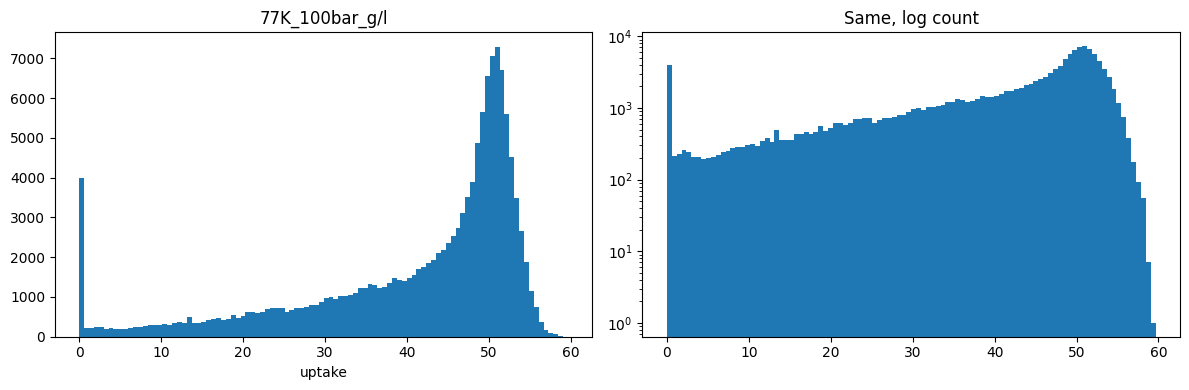


Top 15 MOFs by target:
name
hMOF-5030110    59.6445
hMOF-5028054    58.8790
hMOF-5081276    58.6376
hMOF-5058696    58.5759
hMOF-5058548    58.5752
hMOF-5030107    58.5364
hMOF-5082354    58.5151
hMOF-5033493    58.5053
hMOF-5030280    58.4400
hMOF-5033300    58.4200
hMOF-5057134    58.3969
hMOF-5079500    58.3919
hMOF-5030113    58.3873
hMOF-5081966    58.3804
hMOF-5029262    58.3787


In [9]:
TARGET = c_77_100 or labels.columns[0]
y = labels[TARGET].dropna()
print(f"Target: {TARGET} | n = {len(y)}")
print(y.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(3))
print(f"Exactly zero: {(y == 0).sum()} | negative: {(y < 0).sum()} | NaN in table: {labels[TARGET].isna().sum()}")
for t in (5, 10, 40, 50):
    print(f"Fraction below {t}: {(y < t).mean():.1%}")
q1, q3 = y.quantile([.25, .75]); iqr = q3 - q1
print(f"IQR outliers: {((y < q1 - 3 * iqr) | (y > q3 + 3 * iqr)).sum()}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(y, bins=100); ax[0].set_title(TARGET); ax[0].set_xlabel("uptake")
ax[1].hist(y, bins=100, log=True); ax[1].set_title("Same, log count")
savefig("target_distribution.png")

print("\nTop 15 MOFs by target:")
print(y.sort_values(ascending=False).head(15).to_string())

In [10]:
# Relationship between conditions (are other columns redundant or informative?)
num_labels = labels.select_dtypes("number")
if num_labels.shape[1] > 1:
    corr = num_labels.corr(method="spearman")
    print("Spearman correlation between label columns:")
    print(corr.round(3).to_string())

Spearman correlation between label columns:
col             77K_100bar_g/l  77K_2bar_g/l
col                                         
77K_100bar_g/l            1.00         -0.13
77K_2bar_g/l             -0.13          1.00


## 6. Metadata properties vs uptake

Numeric metadata columns (6): ['id', 'lcd', 'pld', 'void_fraction', 'surface_area_m2g', 'surface_area_m2cm3']
                       count       mean        std      min        25%        50%         75%         max  missing_%  spearman_vs_target
void_fraction       137953.0      0.621      0.228      0.0      0.501      0.682       0.795       0.967        0.0               0.898
surface_area_m2g    137953.0   2593.072   1711.656      0.0   1115.200   2553.500    3989.000    6947.300        0.0               0.879
lcd                 137953.0      8.983      4.454      0.0      5.750      7.750      11.250      24.750        0.0               0.813
pld                 137953.0      7.453      4.490      0.0      4.250      6.250      10.250      24.750        0.0               0.783
surface_area_m2cm3  137953.0   1651.861    761.432      0.0   1258.000   1859.700    2178.600    3607.000        0.0               0.758
id                  137953.0  84684.453  40500.796  15338.0  49828.0

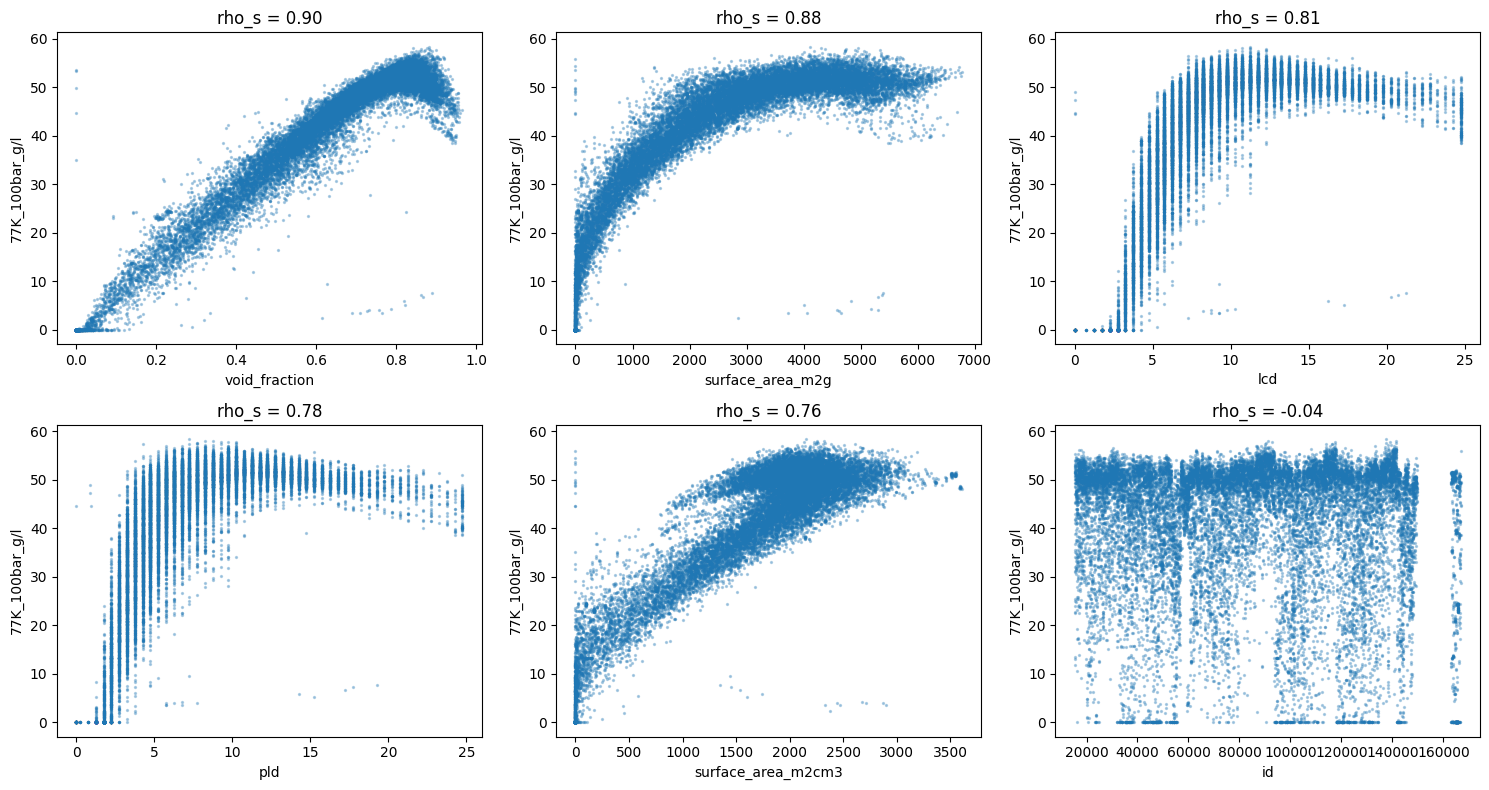

In [11]:
df = meta.set_index("name").join(labels, how="inner")
numeric_meta = [c for c in meta.columns
                if c != "name" and pd.api.types.is_numeric_dtype(meta[c]) and meta[c].nunique() > 5
                and not c.endswith("__len") and not c.endswith("__strlen")]
print(f"Numeric metadata columns ({len(numeric_meta)}):", numeric_meta)

if numeric_meta:
    summary = df[numeric_meta].describe().T
    summary["missing_%"] = 100 * df[numeric_meta].isna().mean()
    summary["spearman_vs_target"] = [df[c].corr(df[TARGET], method="spearman") for c in numeric_meta]
    summary = summary.sort_values("spearman_vs_target", key=abs, ascending=False)
    print(summary.round(3).to_string())
    summary.to_csv(os.path.join(WORK_DIR, "metadata_vs_target.csv"))

    top = summary.index[:6]
    sub = df.sample(min(20000, len(df)), random_state=SEED)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, c in zip(axes.ravel(), top):
        ax.scatter(sub[c], sub[TARGET], s=2, alpha=0.3)
        ax.set_xlabel(c); ax.set_ylabel(TARGET)
        ax.set_title(f"rho_s = {summary.loc[c, 'spearman_vs_target']:.2f}")
    savefig("metadata_scatter.png")
else:
    print("No numeric structural metadata in the JSON files; pore descriptors would need Zeo++.")

## 7. Identifiers: can we do grouped (building block / topology) splits?

In [13]:
id_cols = [c for c in meta.columns
           if any(s in c.lower() for s in ("mofid", "mofkey", "topolog"))
           or c.lower() in ("name", "id", "url", "database", "db", "identifier")]
for c in id_cols:
    print(f"{c:25s} unique = {meta[c].nunique():7d} | example: {str(meta[c].dropna().iloc[0])[:100] if meta[c].notna().any() else None}")

def topology_from(s):
    if not isinstance(s, str):
        return None
    for tag in ("MOFid-v1.", "MOFkey-v1."):
        if tag in s:
            return s.split(tag, 1)[1].split(".")[0].split(";")[0]
    return None

topo_src = next((c for c in meta.columns if "mofkey" in c.lower()), None) or \
           next((c for c in meta.columns if "mofid" in c.lower()), None)
if topo_src:
    meta["topology"] = meta[topo_src].map(topology_from)
    meta["building_blocks"] = meta[topo_src].map(
        lambda s: s.split("MOFkey-v1.")[0] if isinstance(s, str) and "MOFkey-v1." in s
        else (s.split(" ")[0] if isinstance(s, str) else None))
    print(f"\nParsed from '{topo_src}':")
    print(f"  topologies: {meta['topology'].nunique()} | building-block sets: {meta['building_blocks'].nunique()}")
    print(meta["topology"].value_counts().head(15).to_string())
    t = meta.set_index("name").join(labels[TARGET]).groupby("topology")[TARGET].agg(["count", "mean", "std"])
    print("\nUptake by topology (largest groups):")
    print(t.sort_values("count", ascending=False).head(15).round(2).to_string())
    bb = meta["building_blocks"].value_counts()
    print(f"\nBuilding-block groups: median size {bb.median():.0f}, largest {bb.max()}, "
          f"groups of size 1: {(bb == 1).sum()}")
else:
    print("\nNo MOFid / MOFkey field found. Grouped splits would need building blocks derived from the CIFs.")

name                      unique =  137953 | example: hMOF-0
id                        unique =  137953 | example: 15339
url                       unique =  137953 | example: /mofs/15339.json
mofid                     unique =  112310 | example: [O-]C(=O)c1ccc(cc1)C(=O)[O-].[Zn][O]([Zn])([Zn])[Zn] MOFid-v1.pcu.cat0
mofkey                    unique =   73272 | example: Zn.KKEYFWRCBNTPAC.MOFkey-v1.pcu
database                  unique =       1 | example: hMOF
mofid__strlen             unique =     554 | example: 391.0
topology                  unique =      25 | example: pcu

Parsed from 'mofkey':
  topologies: 25 | building-block sets: 73161
topology
pcu        96666
ERROR       6213
rna         5266
UNKNOWN     1604
dia         1551
tbo          849
hex          752
sql          682
fcu          445
nbo          113
bct          109
cpf           35
fse           30
hcb           28
bcu           27

Uptake by topology (largest groups):
          count   mean    std
topology           

## 8. JSON ↔ CIF matching

In [14]:
j, c = set(json_index), set(cif_index)
print(f"Matched: {len(j & c)} | JSON only: {len(j - c)} | CIF only: {len(c - j)}")
print("JSON-only examples:", sorted(j - c)[:5])
print("CIF-only examples :", sorted(c - j)[:5])
embedded = [k for k in meta.columns if k.endswith("__strlen")]
print("Long string fields (possible embedded CIF):", embedded)

Matched: 137953 | JSON only: 0 | CIF only: 0
JSON-only examples: []
CIF-only examples : []
Long string fields (possible embedded CIF): ['cif__strlen', 'mofid__strlen']


## 9. Structure statistics from a CIF sample

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.8/825.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.0 MB/s eta 0:00:00


  0%|          | 0/5000 [00:00<?, ?it/s]

Parse errors: 0
       n_atoms  volume_A3  density_pmg  n_elements        a        b        c
count  5000.00    5000.00      5000.00     5000.00  5000.00  5000.00  5000.00
mean    138.91    4143.57         0.93        5.00    15.28    16.26    14.76
std      98.19    4199.70         0.52        0.67     5.15     5.16     4.75
min      16.00     264.93         0.14        3.00     6.39     6.39     7.08
25%      73.00    1799.46         0.57        5.00    11.79    12.76    11.17
50%     110.00    3089.71         0.83        5.00    14.91    15.94    14.42
75%     177.00    5004.94         1.17        5.00    17.70    18.22    17.08
max     975.00   55381.73         4.25        6.00    42.78    42.78    42.79


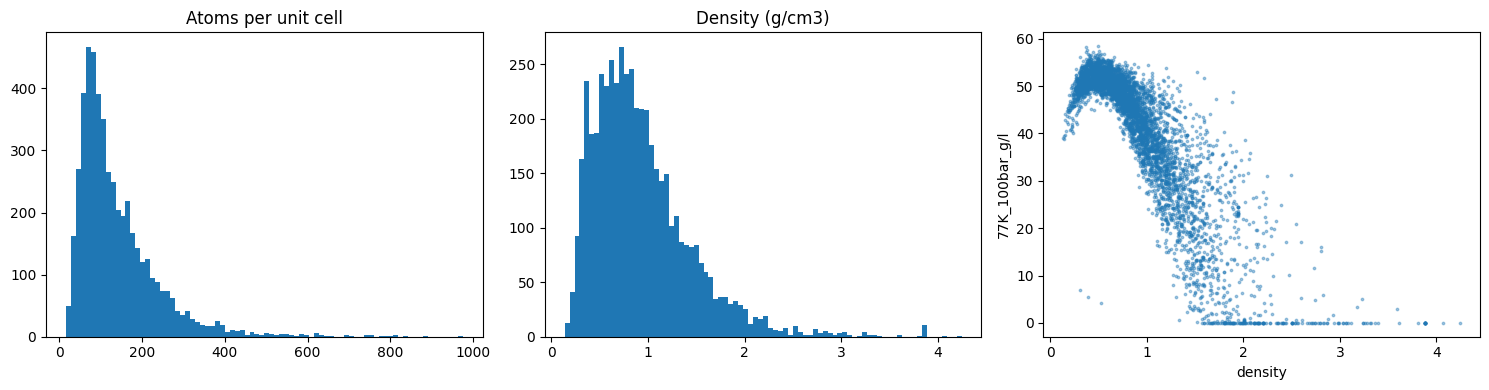

In [15]:
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pymatgen"], check=True)
from pymatgen.core import Structure

def struct_stats(name):
    warnings.filterwarnings("ignore")
    try:
        s = Structure.from_file(cif_index[name])
        comp = s.composition
        metals = sorted({e.symbol for e in comp.elements if e.is_metal})
        return {"name": name, "n_atoms": len(s), "volume_A3": s.volume, "density_pmg": s.density,
                "formula": comp.reduced_formula, "n_elements": len(comp.elements),
                "metals": ",".join(metals), "a": s.lattice.a, "b": s.lattice.b, "c": s.lattice.c}
    except Exception as e:
        return {"name": name, "error": str(e)[:80]}

matched = sorted(set(json_index) & set(cif_index) & set(labels.index))
cif_sample = random.Random(SEED).sample(matched, min(N_CIF_SAMPLE, len(matched)))
with Pool(cpu_count()) as pool:
    st = pd.DataFrame(list(tqdm(pool.imap(struct_stats, cif_sample, chunksize=20), total=len(cif_sample))))
st = st.set_index("name").join(labels[TARGET])
print("Parse errors:", st["error"].notna().sum() if "error" in st else 0)
print(st[["n_atoms", "volume_A3", "density_pmg", "n_elements", "a", "b", "c"]].describe().round(2).to_string())
st.to_csv(os.path.join(WORK_DIR, "structure_sample.csv"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(st.n_atoms.dropna(), bins=80); axes[0].set_title("Atoms per unit cell")
axes[1].hist(st.density_pmg.dropna(), bins=80); axes[1].set_title("Density (g/cm3)")
axes[2].scatter(st.density_pmg, st[TARGET], s=3, alpha=0.4); axes[2].set_xlabel("density"); axes[2].set_ylabel(TARGET)
savefig("structure_stats.png")

           count   mean  median    std
metal_set                             
Zn          3164  42.15   47.63  12.96
Cu          1380  39.47   45.39  14.98
V            292  30.61   36.51  17.89
Zr           164  38.59   41.46  10.67


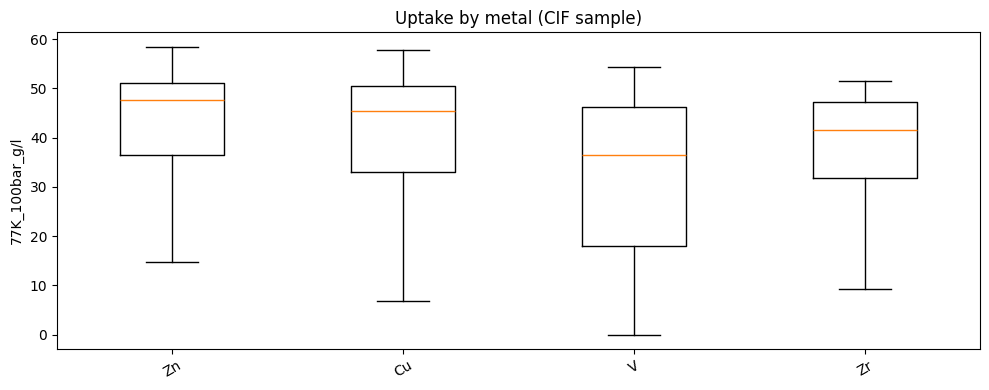

In [16]:
# Uptake by metal and the Cu question
st["metal_set"] = st["metals"].fillna("none").replace("", "none")
by_metal = st.groupby("metal_set")[TARGET].agg(["count", "mean", "median", "std"]).sort_values("count", ascending=False)
print(by_metal.head(15).round(2).to_string())

top_metals = by_metal.index[:8]
plt.figure(figsize=(10, 4))
plt.boxplot([st.loc[st.metal_set == m, TARGET].dropna() for m in top_metals], showfliers=False)
plt.xticks(range(1, len(top_metals) + 1), top_metals, rotation=30)
plt.ylabel(TARGET); plt.title("Uptake by metal (CIF sample)")
savefig("uptake_by_metal.png")

# Does the JSON density agree with the CIF density?
dens_cols = [c for c in meta.columns if "dens" in c.lower()]
for c in dens_cols:
    both = st.join(meta.set_index("name")[c]).dropna(subset=[c, "density_pmg"])
    if len(both):
        print(f"{c} vs pymatgen density: Pearson r = {both[c].corr(both.density_pmg):.4f}, "
              f"median ratio = {(both[c] / both.density_pmg).median():.3f}")

## 10. Near-duplicates (leakage risk for random splits)

In [17]:
fp = st.dropna(subset=["formula"]).copy()
fp["fingerprint"] = fp.formula + "|" + fp.n_atoms.astype(str) + "|" + fp.density_pmg.round(3).astype(str)
groups = fp.groupby("fingerprint")
dup_groups = groups.filter(lambda g: len(g) > 1)
print(f"In a {len(fp)}-structure sample: {dup_groups.fingerprint.nunique()} fingerprints shared by "
      f"{len(dup_groups)} structures ({len(dup_groups) / len(fp):.1%})")
if len(dup_groups):
    spread = dup_groups.groupby("fingerprint")[TARGET].agg(["count", "min", "max"])
    spread["range"] = spread["max"] - spread["min"]
    print("Label spread inside duplicate groups:")
    print(spread["range"].describe().round(3))

fp["formula_only"] = fp.formula
same_formula = fp.groupby("formula_only").size()
print(f"\nStructures sharing a reduced formula with another sampled structure: "
      f"{same_formula[same_formula > 1].sum()} of {len(fp)}")
print("(High numbers mean many close chemical relatives, so a random split overestimates performance.)")

In a 5000-structure sample: 100 fingerprints shared by 268 structures (5.4%)
Label spread inside duplicate groups:
count    100.000
mean       0.662
std        1.045
min        0.000
25%        0.106
50%        0.362
75%        0.661
max        6.917
Name: range, dtype: float64

Structures sharing a reduced formula with another sampled structure: 941 of 5000
(High numbers mean many close chemical relatives, so a random split overestimates performance.)


## 11. SUMMARY: send this block back

In [18]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"JSON files: {len(json_index)} | CIF files: {len(cif_index)} | matched: {len(set(json_index) & set(cif_index))}")
print(f"Adsorbates: {iso.adsorbate.value_counts().to_dict()}")
print(f"H2 conditions (T K, P, units -> n MOFs):")
for _, r in cond[cond.adsorbate.str.contains('Hydrogen', case=False, na=False)].iterrows():
    print(f"   {r.T_K} K | {r.pressure} {r.p_units} | {r.units} -> {r.n_MOFs}")
print(f"Main target: {TARGET} | n = {len(y)} | mean {y.mean():.2f} | median {y.median():.2f} | "
      f"zeros {(y == 0).sum()} | negatives {(y < 0).sum()}")
print(f"Deliverable capacity available: {'deliverable_77K100_160K5' in labels.columns}")
print(f"Numeric metadata columns: {numeric_meta}")
if numeric_meta:
    print("Top correlations with target:", summary["spearman_vs_target"].head(6).round(3).to_dict())
print(f"Topology/building-block info: {topo_src or 'none'}"
      + (f" ({meta['topology'].nunique()} topologies, {meta['building_blocks'].nunique()} building-block sets)" if topo_src else ""))
print(f"Near-duplicate fingerprint share in sample: {len(dup_groups) / max(len(fp), 1):.1%}")
print(f"Outputs saved in: {WORK_DIR}")

SUMMARY
JSON files: 137953 | CIF files: 137953 | matched: 137953
Adsorbates: {'Hydrogen': 275906}
H2 conditions (T K, P, units -> n MOFs):
   77 K | 2 bar | g/l -> 137953
   77 K | 100 bar | g/l -> 137953
Main target: 77K_100bar_g/l | n = 137953 | mean 40.75 | median 46.61 | zeros 3114 | negatives 0
Deliverable capacity available: False
Numeric metadata columns: ['id', 'lcd', 'pld', 'void_fraction', 'surface_area_m2g', 'surface_area_m2cm3']
Top correlations with target: {'void_fraction': 0.898, 'surface_area_m2g': 0.879, 'lcd': 0.813, 'pld': 0.783, 'surface_area_m2cm3': 0.758, 'id': -0.039}
Topology/building-block info: mofkey (25 topologies, 73161 building-block sets)
Near-duplicate fingerprint share in sample: 5.4%
Outputs saved in: /kaggle/working/eda


In [19]:
d = meta.set_index("name").join(labels)
zero = d[TARGET] == 0
print("PLD (A) of zero-uptake MOFs:\n", d.loc[zero, "pld"].describe().round(2))
print("\nPLD (A) of non-zero MOFs:\n", d.loc[~zero, "pld"].describe().round(2))
for t in (2.5, 2.9, 3.2):
    print(f"PLD < {t} A: {(d.pld < t).sum()} MOFs, of which zero uptake: {(zero & (d.pld < t)).sum()}")

dc = d["77K_100bar_g/l"] - d["77K_2bar_g/l"]
print("\nDeliverable capacity (100 -> 2 bar, 77 K):\n", dc.describe().round(2))
print("Spearman DC vs void fraction:", round(dc.corr(d.void_fraction, method="spearman"), 3))

PLD (A) of zero-uptake MOFs:
 count    3114.00
mean        1.33
std         0.64
min         0.00
25%         1.25
50%         1.25
75%         1.75
max         3.75
Name: pld, dtype: float64

PLD (A) of non-zero MOFs:
 count    134839.00
mean          7.59
std           4.44
min           0.00
25%           4.25
50%           6.25
75%          10.25
max          24.75
Name: pld, dtype: float64
PLD < 2.5 A: 10337 MOFs, of which zero uptake: 3078
PLD < 2.9 A: 16861 MOFs, of which zero uptake: 3107
PLD < 3.2 A: 16861 MOFs, of which zero uptake: 3107

Deliverable capacity (100 -> 2 bar, 77 K):
 count    137953.00
mean         23.68
std          14.98
min         -23.27
25%           9.95
50%          22.98
75%          38.65
max          50.09
dtype: float64
Spearman DC vs void fraction: 0.934


In [20]:
d["dc"] = d["77K_100bar_g/l"] - d["77K_2bar_g/l"]

for t in (0, -1, -5, -10):
    print(f"DC < {t}: {(d.dc < t).sum()} MOFs")

neg = d[d.dc < -1]
print("\nNegative-DC MOFs, geometry:")
print(neg[["pld", "lcd", "void_fraction", "surface_area_m2g", "77K_2bar_g/l", "77K_100bar_g/l", "dc"]]
      .describe().round(2).to_string())
print("\nWorst 10:")
print(neg.sort_values("dc")[["pld", "lcd", "void_fraction", "77K_2bar_g/l", "77K_100bar_g/l", "dc"]]
      .head(10).to_string())

small = d[d.pld < 2.9]
print("\nSmall-PLD MOFs: LCD for zero vs non-zero uptake")
print(small.groupby(small[TARGET] == 0)["lcd"].describe().round(2).to_string())

DC < 0: 392 MOFs
DC < -1: 81 MOFs
DC < -5: 18 MOFs
DC < -10: 12 MOFs

Negative-DC MOFs, geometry:
         pld    lcd  void_fraction  surface_area_m2g  77K_2bar_g/l  77K_100bar_g/l     dc
count  81.00  81.00          81.00             81.00         81.00           81.00  81.00
mean    4.92   6.89           0.45           2457.97          9.93            5.64  -4.29
std     3.41   3.79           0.32           2339.80          4.30            2.94   4.81
min     1.25   2.75           0.04              0.00          3.25            1.91 -23.27
25%     2.25   3.25           0.11              0.70          7.05            3.74  -4.61
50%     4.75   7.25           0.63           3437.00          8.53            4.30  -2.19
75%     6.25   9.25           0.76           4777.70         11.62            7.45  -1.31
max    16.75  18.75           0.83           5603.10         25.75           17.05  -1.02

Worst 10:
               pld   lcd  void_fraction  77K_2bar_g/l  77K_100bar_g/l        dc
n

In [21]:
d["id_block"] = d.index.str.extract(r"hMOF-(\d+)", expand=False).astype(int) // 1000
suspect = (d.void_fraction > 0.5) & (d["77K_100bar_g/l"] < 10)
print("Suspicious MOFs (void fraction > 0.5 but 100-bar uptake < 10 g/L):", suspect.sum())
print("\nBy ID block (x1000):")
print(d[suspect].id_block.value_counts().head(10).to_string())
print("\nShare of each block that is suspicious (top 10):")
rate = d.groupby("id_block").apply(lambda g: ((g.void_fraction > 0.5) & (g["77K_100bar_g/l"] < 10)).mean())
print(rate.sort_values(ascending=False).head(10).round(3).to_string())

blk = d[d.id_block == 3001]
print(f"\nhMOF-3001xxx: {len(blk)} MOFs")
print(blk[["void_fraction", "77K_2bar_g/l", "77K_100bar_g/l"]].describe().round(2).to_string())
print("\nTop suspicious names (for RASPA checks):")
print(d[suspect].sort_values("void_fraction", ascending=False).head(10)[
    ["void_fraction", "lcd", "77K_2bar_g/l", "77K_100bar_g/l"]].to_string())

Suspicious MOFs (void fraction > 0.5 but 100-bar uptake < 10 g/L): 93

By ID block (x1000):
id_block
3001    91
5054     1
7001     1

Share of each block that is suspicious (top 10):
id_block
3001    0.091
5054    0.001
7001    0.001
3       0.000
0       0.000
1       0.000
2       0.000
7       0.000
8       0.000
9       0.000

hMOF-3001xxx: 1000 MOFs
       void_fraction  77K_2bar_g/l  77K_100bar_g/l
count        1000.00       1000.00         1000.00
mean            0.82          7.05           42.42
std             0.09          5.08           12.28
min             0.45          1.72            2.17
25%             0.78          3.50           42.19
50%             0.84          5.48           45.85
75%             0.89          8.36           48.79
max             0.95         27.03           54.78

Top suspicious names (for RASPA checks):
              void_fraction    lcd  77K_2bar_g/l  77K_100bar_g/l
name                                                            
hMOF-300184

In [22]:
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "CoolProp"], check=True)
from CoolProp.CoolProp import PropsSI

rho_bulk_100 = PropsSI("D", "T", 77, "P", 100e5, "Hydrogen")   # kg/m3 = g/L
rho_bulk_2 = PropsSI("D", "T", 77, "P", 2e5, "Hydrogen")
print(f"Bulk H2 density at 77 K: 100 bar = {rho_bulk_100:.1f} g/L | 2 bar = {rho_bulk_2:.2f} g/L")

d["floor_100"] = d.void_fraction * rho_bulk_100
d["below_floor"] = d["77K_100bar_g/l"] < 0.8 * d.floor_100
print("\nMOFs below 80% of the physical floor:", d.below_floor.sum())
print("By ID block:\n", d[d.below_floor].id_block.value_counts().head(5).to_string())

flag = d.below_floor | (d.dc < -1)
print(f"\nTotal flagged (below floor OR DC < -1): {flag.sum()}")
print("By ID block:\n", d[flag].id_block.value_counts().head(5).to_string())
d["label_flag"] = flag
d[["label_flag"]].to_csv(os.path.join(WORK_DIR, "label_flags.csv"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 50.7 MB/s eta 0:00:00
Bulk H2 density at 77 K: 100 bar = 31.3 g/L | 2 bar = 0.63 g/L

MOFs below 80% of the physical floor: 4154
By ID block:
 id_block
6000    289
6001    185
20      171
32      147
5059    145

Total flagged (below floor OR DC < -1): 4189
By ID block:
 id_block
6000    289
6001    185
20      171
32      147
5059    145



Accessible MOFs below 50% of floor: 122
id_block
3001    91
1002     6
21       2
1001     2
5062     2
19       1
22       1
1003     1

Accessible MOFs below 80% of floor: 140
id_block
3001    91
1002     9
1001     4
21       3
36       2
27       2
5037     2
5017     2

Ratio to floor, accessible MOFs:
count    121073.000
mean          2.117
std           0.224
min           0.000
0.1%          0.500
1%            1.538
5%            1.756
50%           2.137
max           5.725


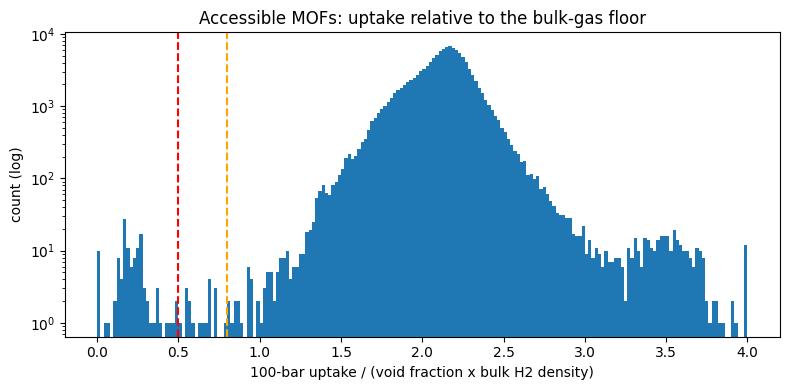

In [23]:
d["ratio_to_floor"] = d["77K_100bar_g/l"] / d.floor_100.replace(0, np.nan)
accessible = d.pld >= 3.2          # windows wide enough for H2

for thr in (0.5, 0.8):
    f = accessible & (d.ratio_to_floor < thr)
    print(f"\nAccessible MOFs below {thr:.0%} of floor: {f.sum()}")
    print(d[f].id_block.value_counts().head(8).to_string())

print("\nRatio to floor, accessible MOFs:")
print(d.loc[accessible, "ratio_to_floor"].describe(percentiles=[.001, .01, .05, .5]).round(3).to_string())

plt.figure(figsize=(8, 4))
plt.hist(d.loc[accessible, "ratio_to_floor"].clip(0, 4), bins=200, log=True)
plt.axvline(0.5, color="r", ls="--"); plt.axvline(0.8, color="orange", ls="--")
plt.xlabel("100-bar uptake / (void fraction x bulk H2 density)"); plt.ylabel("count (log)")
plt.title("Accessible MOFs: uptake relative to the bulk-gas floor")
savefig("ratio_to_floor.png")